In [1]:
import numpy as np
import pandas as pd

inputfile = '../data/GoodsOrder.csv'   # 数据文件
data = pd.read_csv(inputfile,encoding = 'gbk')  # 读取数据

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43367 entries, 0 to 43366
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      43367 non-null  int64 
 1   Goods   43367 non-null  object
dtypes: int64(1), object(1)
memory usage: 677.7+ KB


In [3]:
data = data['id']
description = [len(data), data.min(), data.max(), data.std()]  # 依次计算总数、最小值、最大值、标准差
description = pd.DataFrame(description, index=['总数', '最小值', '最大值', '标准差']).T  # 将结果存入数据框
print('描述性统计结果：\n', np.round(description))  # 输出结果

描述性统计结果：
         总数  最小值     最大值     标准差
0  43367.0  1.0  9835.0  2843.0


In [4]:
inputfile = '../data/GoodsOrder.csv'   # 数据文件
data = pd.read_csv(inputfile,encoding = 'gbk')  # 读取数据

group = data.groupby('Goods')['id'].count().reset_index()  # 对商品进行分类汇总，统计每个商品的销量
sorted = group.sort_values('id', ascending=False)  # 按照销量降序排列
print('销量排行前10商品的销量:\n', sorted.head(10))  # 排序并查看前10位热销商品

销量排行前10商品的销量:
      Goods    id
7     全脂牛奶  2513
8     其他蔬菜  1903
155    面包卷  1809
134     苏打  1715
150     酸奶  1372
99     瓶装水  1087
70   根茎类蔬菜  1072
85    热带水果  1032
143    购物袋   969
160     香肠   924


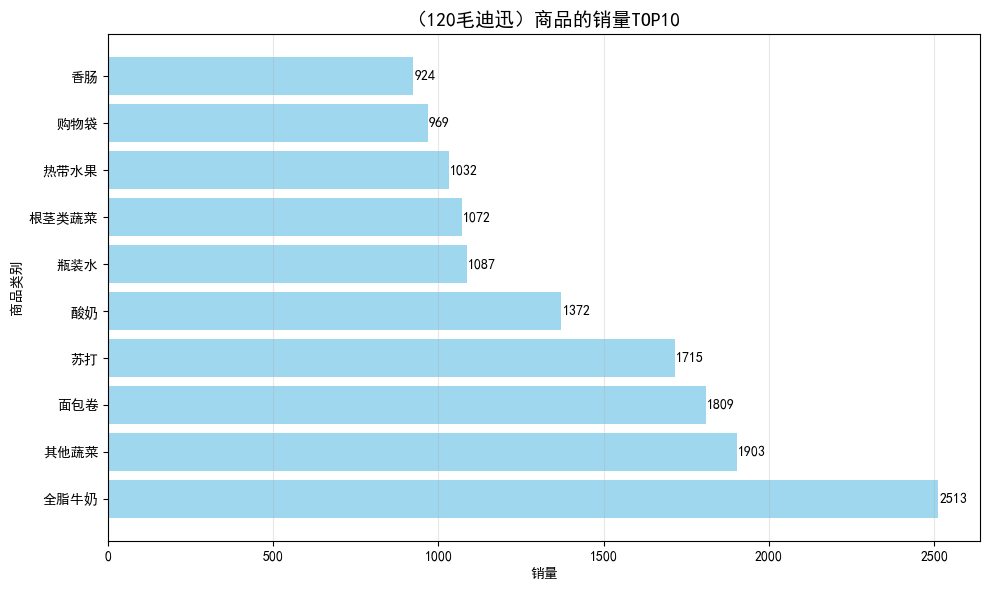

In [5]:
# 画条形图展示出销量排行前10商品的销量
import matplotlib.pyplot as plt

# 获取销量前10的商品数据
top10 = sorted.head(10)

x = top10['id'].values 
y = top10['Goods'].values   

plt.figure(figsize = (10, 6))  # 设置画布大小 
bars = plt.barh(y, x, color='skyblue', alpha=0.8)  # 添加颜色和透明度

# 在条形上显示数值
for i, v in enumerate(x):
    plt.text(v + 3, i, str(v), va='center', fontsize=10)

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    

plt.xlabel('销量')  # 设置x轴标题
plt.ylabel('商品类别')  # 设置y轴标题
plt.title('（120毛迪迅）商品的销量TOP10', fontsize=14, fontweight='bold')  # 设置标题
plt.grid(axis='x', alpha=0.3)  # 添加网格线
plt.tight_layout()  # 自动调整布局
plt.savefig('../tmp/top10.png', dpi=300, bbox_inches='tight')  # 保存图片
plt.show()  # 展示图片

In [6]:
# 销量排行前10商品的销量占比
data_nums = data.shape[0]
print("销量排行前10商品的销量占比:")
print("=" * 50)
for i, row in sorted.head(10).iterrows():
    percentage = (row['id'] / data_nums) * 100
    print(f'商品: {row["Goods"]}, 销量: {row["id"]}, 占比: {percentage:.2f}%')

销量排行前10商品的销量占比:
商品: 全脂牛奶, 销量: 2513, 占比: 5.79%
商品: 其他蔬菜, 销量: 1903, 占比: 4.39%
商品: 面包卷, 销量: 1809, 占比: 4.17%
商品: 苏打, 销量: 1715, 占比: 3.95%
商品: 酸奶, 销量: 1372, 占比: 3.16%
商品: 瓶装水, 销量: 1087, 占比: 2.51%
商品: 根茎类蔬菜, 销量: 1072, 占比: 2.47%
商品: 热带水果, 销量: 1032, 占比: 2.38%
商品: 购物袋, 销量: 969, 占比: 2.23%
商品: 香肠, 销量: 924, 占比: 2.13%


In [7]:
import pandas as pd
inputfile1 = '../data/GoodsOrder.csv'
inputfile2 = '../data/GoodsTypes.csv'
data = pd.read_csv(inputfile1, encoding='gbk')  # 读入销售数据
types = pd.read_csv(inputfile2, encoding='gbk')  # 读入商品类别数据

group = data.groupby('Goods')['id'].count().reset_index()  # 分组统计每个商品的销量
sort = group.sort_values('id', ascending=False)  # 按销量降序排序
data_nums = data.shape[0]  # 总量

sort_links = pd.merge(sort, types, on='Goods')  # 合并两个dataframe 根据Goods列
# 根据类别求和，每个商品类别的总量，并排序
sort_link = sort_links.groupby('Types')['id'].sum().reset_index()  # 根据类别求和，每个商品类别的总量
sort_link = sort_link.sort_values('id', ascending=False)  # 按销量降序排序

# 求百分比，然后更换列名，最后输出到文件
sort_link['percent'] = sort_link['id'] / data_nums * 100  # 求百分比
sort_link.columns = ['Types', 'num', 'percent']  # 重置列名

print('各类别商品的销量及其占比:')
print('=' * 50)
for i, row in sort_link.iterrows():
    print(f"{i+1:2d}. {row['Types']:10} 销量: {row['num']:5d} 占比: {row['percent']:6.2f}%")

# 保存结果到文件
sort_link.to_csv('../tmp/type_percent.csv', index=False, encoding='gbk')

各类别商品的销量及其占比:
 9. 非酒精饮料      销量:  7594 占比:  17.51%
 6. 西点         销量:  7192 占比:  16.58%
 1. 果蔬         销量:  7146 占比:  16.48%
 4. 米粮调料       销量:  5185 占比:  11.96%
 3. 百货         销量:  5141 占比:  11.85%
 5. 肉类         销量:  4870 占比:  11.23%
 7. 酒精饮料       销量:  2287 占比:   5.27%
10. 食品类        销量:  1870 占比:   4.31%
 8. 零食         销量:  1459 占比:   3.36%
 2. 熟食         销量:   541 占比:   1.25%


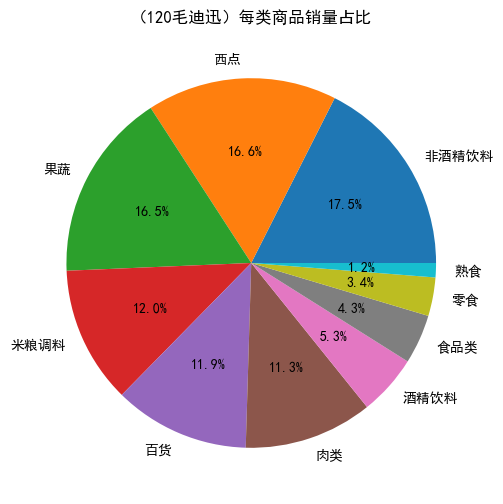

In [8]:
# 画饼图展示每类商品销量占比
import matplotlib.pyplot as plt
data = sort_link['num']  # 各类别的销量数据
labels = sort_link['Types']  # 各类别的名称
plt.figure(figsize=(8, 6))  # 设置画布大小   
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=0)  # 画饼图
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设S置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.title('（120毛迪迅）每类商品销量占比')  # 设置标题
plt.savefig('../tmp/persent.png')  # 把图片以.png格式保存
plt.show()

In [9]:
# 非酒精饮料内部商品的销量及其占比
# 先筛选“非酒精饮料”类型的商品，然后求百分比，然后输出结果到文件。
selected = sort_links[sort_links['Types'] == '非酒精饮料'].sort_values('id', ascending=False)  # 挑选商品类别为"非酒精饮料"并排序
child_nums = selected['id'].sum()  # 对所有的"非酒精饮料"求和
selected['child_percent'] = selected['id'] / child_nums * 100  # 求百分比
selected.columns = ['Goods', 'num', 'Types', 'percent']  # 重置列名

print('非酒精饮料内部商品的销量及其占比:')
print('=' * 60)
for i, row in selected.iterrows():
    print(f"{i+1:2d}. {row['Goods']:15} 销量: {row['num']:4d} 占比: {row['percent']:6.2f}%")

print(f"\n非酒精饮料总销量: {child_nums}")
print(f"商品种类数: {len(selected)}")

# 保存结果到文件
selected.to_csv('../tmp/non_alcoholic_drinks.csv', index=False, encoding='gbk')

非酒精饮料内部商品的销量及其占比:
 1. 全脂牛奶            销量: 2513 占比:  33.09%
 4. 苏打              销量: 1715 占比:  22.58%
 6. 瓶装水             销量: 1087 占比:  14.31%
17. 水果/蔬菜汁          销量:  711 占比:   9.36%
23. 咖啡              销量:  571 占比:   7.52%
39. 超高温杀菌的牛奶        销量:  329 占比:   4.33%
46. 其他饮料            销量:  279 占比:   3.67%
52. 一般饮料            销量:  256 占比:   3.37%
102. 速溶咖啡            销量:   73 占比:   0.96%
126. 茶               销量:   38 占比:   0.50%
145. 可可饮料            销量:   22 占比:   0.29%

非酒精饮料总销量: 7594
商品种类数: 11


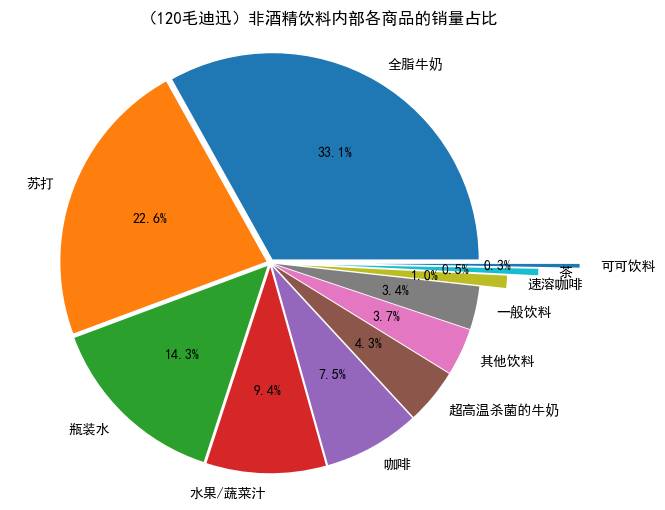

In [10]:
# 画饼图展示非酒精饮品内部各商品的销量占比
import matplotlib.pyplot as plt
data = selected['num']  # 非酒精饮料内部各商品的销量数据
labels = selected['Goods']  # 非酒精饮料内部各商品的名称
plt.figure(figsize = (8,6))  # 设置画布大小 
# 计算百分比
percentages = data / data.sum() * 100
explode = []
for p in percentages:
    if p < 0.3:
        explode.append(0.5)    # 极小饼块：最大突出
    elif p < 0.6:
        explode.append(0.3)   # 小饼块：中等突出
    elif p < 1:
        explode.append(0.15)   # 大饼块：中等突出
    else:
        explode.append(0.02)   # 最大饼块：最小突出
plt.pie(data, labels=labels, autopct='%1.1f%%', explode=explode, startangle=0)  # 画饼图
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.title("（120毛迪迅）非酒精饮料内部各商品的销量占比")  # 设置标题
plt.axis('equal')
plt.savefig('../tmp/child_persent.png')  # 保存图形
plt.show()  # 展示图形

In [11]:
import pandas as pd
inputfile='../data/GoodsOrder.csv'
data = pd.read_csv(inputfile,encoding = 'gbk')
data

,id,Goods
0,1,柑橘类水果
1,1,人造黄油
2,1,即食汤
3,1,半成品面包
4,2,咖啡
...,...,...
43362,9835,鸡
43363,9835,其他蔬菜
43364,9835,购物袋
43365,9835,热带水果


In [12]:
#在Goods前加分隔符','
data['Goods'] = ',' + data['Goods']
data['Goods']

0        ,柑橘类水果
1         ,人造黄油
2          ,即食汤
3        ,半成品面包
4           ,咖啡
          ...  
43362        ,鸡
43363     ,其他蔬菜
43364      ,购物袋
43365     ,热带水果
43366        ,醋
Name: Goods, Length: 43367, dtype: object

In [13]:
# 根据id对“Goods”列合并
data = data.groupby('id')['Goods'].apply(','.join).reset_index()
data

,id,Goods
0,1,",柑橘类水果,,人造黄油,,即食汤,,半成品面包"
1,2,",咖啡,,热带水果,,酸奶"
2,3,",全脂牛奶"
3,4,",奶油乳酪,,肉泥,,仁果类水果,,酸奶"
4,5,",炼乳,,长面包,,其他蔬菜,,全脂牛奶"
...,...,...
9830,9831,",牛肉,,黄油,,鸡,,巧克力,,柑橘类水果,,咖啡,,面粉,,葡萄,,汉堡肉,,卫生用品,..."
9831,9832,",烹饪巧克力"
9832,9833,",黄油,,鸡,,柑橘类水果,,保鲜膜/袋,,本地蛋类,,冷冻甜点,,其他蔬菜,,面包卷,,朗..."
9833,9834,",瓶装啤酒,,瓶装水,,半成品面包,,苏打"


In [14]:
# 对合并的商品列转换数据格式
data['Goods'] = data['Goods'].str.strip(',')  # 去除开头和结尾的逗号
data['Goods'] = data['Goods'].str.replace(',,', ',', regex=True)  # 去除连续逗号
    
data_list = [[x] for x in data['Goods']]
data_list

[['柑橘类水果,人造黄油,即食汤,半成品面包'],
 ['咖啡,热带水果,酸奶'],
 ['全脂牛奶'],
 ['奶油乳酪,肉泥,仁果类水果,酸奶'],
 ['炼乳,长面包,其他蔬菜,全脂牛奶'],
 ['腐蚀性清洁剂,黄油,白饭,全脂牛奶,酸奶'],
 ['面包卷'],
 ['瓶装啤酒,开胃酒,其他蔬菜,面包卷,超高温杀菌的牛奶'],
 ['盆栽'],
 ['谷物,全脂牛奶'],
 ['瓶装水,巧克力,其他蔬菜,热带水果,白面包'],
 ['瓶装水,黄油,柑橘类水果,凝乳,碗碟,面粉,热带水果,全脂牛奶,酸奶'],
 ['牛肉'],
 ['冷冻热狗肠,面包卷,苏打'],
 ['鸡,热带水果'],
 ['黄油,水果/蔬菜汁,报纸,糖'],
 ['水果/蔬菜汁'],
 ['包装水果/蔬菜'],
 ['巧克力'],
 ['特制门锁'],
 ['其他蔬菜'],
 ['酪,糕点'],
 ['全脂牛奶'],
 ['奶油乳酪,一般清洁剂,报纸,融化奶酪,热带水果'],
 ['浴室清洁剂,糖果,面粉,冷冻甜点,其他蔬菜,面包卷,根茎类蔬菜,咸点心,甜食,热带水果,威化饼'],
 ['瓶装水,罐装啤酒'],
 ['酸奶'],
 ['巧克力,面包卷,香肠,苏打'],
 ['其他蔬菜'],
 ['黑面包,罐装啤酒,水果/蔬菜汁,报纸,购物袋,苏打'],
 ['一般饮料,瓶装水,特制门锁,酸奶'],
 ['瓶装水,汉堡肉,卫生用品,餐巾,其他蔬菜,面包卷,香辛料'],
 ['一般饮料,其他蔬菜,根茎类蔬菜,糖,全脂牛奶'],
 ['腐蚀性清洁剂,甜味剂,莓果,其他蔬菜,猪肉,苏打,酸奶油,全脂牛奶'],
 ['牛肉,一般清洁剂,葡萄'],
 ['糕点,苏打'],
 ['水果/蔬菜汁'],
 ['罐装啤酒'],
 ['甜点,其他蔬菜,根茎类蔬菜,全脂牛奶'],
 ['柑橘类水果,报纸,面包干'],
 ['罐装啤酒,面包卷,香肠,购物袋,苏打,特制门锁'],
 ['黑面包,糖果,谷物,咖啡,本地蛋类,糕点,根茎类蔬菜,苏打,糖,热带水果,威化饼,全脂牛奶,酸奶'],
 ['莓果,酸奶'],
 ['罐装啤酒'],
 ['瓶装水,酪,奶油乳酪,报纸,面包卷,苏打,水果奶油涂抹酱,酸奶'],
 ['咖啡'],
 ['瓶装水,糕点'],
 ['面包卷'],
 ['其他饮料'],
 ['瓶装水,黄油

In [15]:
# 分割商品名为每个元素
data_translation = [i[0].split(',') for i in data_list]
print('数据转换结果的前5个元素：\n', data_translation[0:5])

数据转换结果的前5个元素：
 [['柑橘类水果', '人造黄油', '即食汤', '半成品面包'], ['咖啡', '热带水果', '酸奶'], ['全脂牛奶'], ['奶油乳酪', '肉泥', '仁果类水果', '酸奶'], ['炼乳', '长面包', '其他蔬菜', '全脂牛奶']]


In [16]:
# 商品购物篮关联规则模型构建
from numpy import *
 
def loadDataSet():
    return [['a', 'c', 'e'], ['b', 'd'], ['b', 'c'], ['a', 'b', 'c', 'd'], ['a', 'b'], ['b', 'c'], ['a', 'b'],
            ['a', 'b', 'c', 'e'], ['a', 'b', 'c'], ['a', 'c', 'e']]
 
def createC1(dataSet):
    C1 = []
    for transaction in dataSet:
        for item in transaction:
            if not [item] in C1:
                C1.append([item])
    C1.sort()
    # 映射为frozenset唯一性的，可使用其构造字典
    return list(map(frozenset, C1))     
    
# 从候选K项集到频繁K项集（支持度计算）
def scanD(D, Ck, minSupport):
    ssCnt = {}
    for tid in D:   # 遍历数据集
        for can in Ck:  # 遍历候选项
            if can.issubset(tid):  # 判断候选项中是否含数据集的各项
                if not can in ssCnt:
                    ssCnt[can] = 1  # 不含设为1
                else:
                    ssCnt[can] += 1  # 有则计数加1
    numItems = float(len(D))  # 数据集大小
    retList = []  # L1初始化
    supportData = {}  # 记录候选项中各个数据的支持度
    for key in ssCnt:
        support = ssCnt[key] / numItems  # 计算支持度
        if support >= minSupport:
            retList.insert(0, key)  # 满足条件加入L1中
            supportData[key] = support  
    return retList, supportData
 
def calSupport(D, Ck, min_support):
    dict_sup = {}
    for i in D:
        for j in Ck:
            if j.issubset(i):
                if not j in dict_sup:
                    dict_sup[j] = 1
                else:
                    dict_sup[j] += 1
    sumCount = float(len(D))
    supportData = {}
    relist = []
    for i in dict_sup:
        temp_sup = dict_sup[i] / sumCount
        if temp_sup >= min_support:
            relist.append(i)
# 此处可设置返回全部的支持度数据（或者频繁项集的支持度数据）
            supportData[i] = temp_sup
    return relist, supportData
 
# 改进剪枝算法
def aprioriGen(Lk, k):
    retList = []
    lenLk = len(Lk)
    for i in range(lenLk):
        for j in range(i + 1, lenLk):  # 两两组合遍历
            L1 = list(Lk[i])[:k-2]  # 取前k-2个元素
            L2 = list(Lk[j])[:k-2]  # 取前k-2个元素
            L1.sort()
            L2.sort()
            if L1 == L2:  # 前k-1项相等，则可相乘，这样可防止重复项出现
                # 进行剪枝（a1为k项集中的一个元素，b为它的所有k-1项子集）
                a = Lk[i] | Lk[j]  # a为frozenset()集合
                a1 = list(a)
                b = []
                # 遍历取出每一个元素，转换为set，依次从a1中剔除该元素，并加入到b中
                for q in range(len(a1)):
                    t = [a1[q]]
                    tt = frozenset(set(a1) - set(t))
                    b.append(tt)
                t = 0
                for w in b:
                    # 当b（即所有k-1项子集）都是Lk（频繁的）的子集，则保留，否则删除。
                    if w in Lk:
                        t += 1
                if t == len(b):
                    retList.append(b[0] | b[1])
    return retList

def apriori(dataSet, minSupport=0.2):
# 前3条语句是对计算查找单个元素中的频繁项集
    C1 = createC1(dataSet)  # 创建候选1项集
    D = list(map(set, dataSet))  # 使用list()转换为列表
    L1, supportData = calSupport(D, C1, minSupport)  # 计算支持度
    L = [L1]  # 加列表框，使得1项集为一个单独元素
    k = 2
    while (len(L[k - 2]) > 0):  # 是否还有候选集
        Ck = aprioriGen(L[k-2], k)  # 剪枝
        Lk, supK = calSupport(D, Ck, minSupport)  # scan DB to get Lk
        supportData.update(supK)  # 把supk的键值对添加到supportData里
        L.append(Lk)  # L最后一个值为空集
        k += 1
    del L[-1]  # 删除最后一个空集
    return L, supportData  # L为频繁项集，为一个列表，1，2，3项集分别为一个元素

# 生成集合的所有子集
def getSubset(fromList, toList):
    for i in range(len(fromList)):
        t = [fromList[i]]
        tt = frozenset(set(fromList) - set(t))
        if not tt in toList:
            toList.append(tt)
            tt = list(tt)
            if len(tt) > 1:
                getSubset(tt, toList)
 
def calcConf(freqSet, H, supportData, ruleList, minConf=0.7):
    for conseq in H:  #遍历H中的所有项集并计算它们的可信度值
        conf = supportData[freqSet] / supportData[freqSet - conseq]  # 可信度计算，结合支持度数据
        # 提升度lift计算lift = p(a & b) / p(a)*p(b)
        lift = supportData[freqSet] / (supportData[freqSet - conseq] * supportData[conseq])
 
        if conf >= minConf and lift > 1:
            print(freqSet - conseq, '-->', conseq, '支持度', round(supportData[freqSet], 6), '置信度：', round(conf, 6),
                  'lift值为：', round(lift, 6))
            ruleList.append((freqSet - conseq, conseq, conf))
 
# 生成规则
def gen_rule(L, supportData, minConf = 0.7):
    bigRuleList = []
    for i in range(1, len(L)):  # 从二项集开始计算
        for freqSet in L[i]:  # freqSet为所有的k项集
            # 求该三项集的所有非空子集，1项集，2项集，直到k-1项集，用H1表示，为list类型,里面为frozenset类型，
            H1 = list(freqSet)
            all_subset = []
            getSubset(H1, all_subset)  # 生成所有的子集
            calcConf(freqSet, all_subset, supportData, bigRuleList, minConf)
    return bigRuleList
 
if __name__ == '__main__':
    dataSet = data_translation
    L, supportData = apriori(dataSet, minSupport = 0.02)
    rule = gen_rule(L, supportData, minConf = 0.35)

frozenset({'其他蔬菜'}) --> frozenset({'全脂牛奶'}) 支持度 0.074835 置信度： 0.386758 lift值为： 1.513634
frozenset({'酸奶'}) --> frozenset({'全脂牛奶'}) 支持度 0.056024 置信度： 0.401603 lift值为： 1.571735
frozenset({'黄油'}) --> frozenset({'全脂牛奶'}) 支持度 0.027555 置信度： 0.497248 lift值为： 1.946053
frozenset({'柑橘类水果'}) --> frozenset({'全脂牛奶'}) 支持度 0.030503 置信度： 0.36855 lift值为： 1.442377
frozenset({'热带水果'}) --> frozenset({'全脂牛奶'}) 支持度 0.042298 置信度： 0.403101 lift值为： 1.577595
frozenset({'凝乳'}) --> frozenset({'全脂牛奶'}) 支持度 0.026131 置信度： 0.490458 lift值为： 1.919481
frozenset({'根茎类蔬菜'}) --> frozenset({'其他蔬菜'}) 支持度 0.047382 置信度： 0.434701 lift值为： 2.246605
frozenset({'根茎类蔬菜'}) --> frozenset({'全脂牛奶'}) 支持度 0.048907 置信度： 0.448694 lift值为： 1.756031
frozenset({'猪肉'}) --> frozenset({'全脂牛奶'}) 支持度 0.022166 置信度： 0.38448 lift值为： 1.504719
frozenset({'酸奶油'}) --> frozenset({'全脂牛奶'}) 支持度 0.032232 置信度： 0.449645 lift值为： 1.759754
frozenset({'猪肉'}) --> frozenset({'其他蔬菜'}) 支持度 0.021657 置信度： 0.375661 lift值为： 1.941476
frozenset({'酸奶油'}) --> frozenset({'其他蔬菜'})

In [18]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def fp_growth_analysis(transactions, min_support=0.02, min_confidence=0.35):
    """
    FP-Growth算法关联规则分析
    """
    print("=" * 60)
    print("FP-Growth关联规则分析")
    print("=" * 60)
    
    # 数据预处理 - 转换为one-hot编码格式
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df = pd.DataFrame(te_ary, columns=te.columns_)
    
    print(f"数据集形状: {df.shape}")
    print(f"总交易数: {len(transactions)}")
    print(f"商品种类数: {len(te.columns_)}")
    
    # 使用FP-Growth算法挖掘频繁项集
    print(f"\n使用最小支持度: {min_support}")
    frequent_itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
    
    print(f"发现的频繁项集数量: {len(frequent_itemsets)}")
    
    # 按支持度排序
    frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
    
    # 显示前10个频繁项集
    print("\n前10个频繁项集:")
    for idx, row in frequent_itemsets.head(10).iterrows():
        items = list(row['itemsets'])
        print(f"商品组合: {items} | 支持度: {row['support']:.4f}")
    
    # 生成关联规则
    print(f"\n使用最小置信度: {min_confidence}")
    rules = association_rules(frequent_itemsets, metric="confidence", 
                             min_threshold=min_confidence)
    
    print(f"生成的关联规则数量: {len(rules)}")
    
    if len(rules) > 0:
        # 添加提升度排序
        rules = rules.sort_values('lift', ascending=False)
        
        # 显示前10条强关联规则
        print("\n前10条强关联规则:")
        for idx, row in rules.head(10).iterrows():
            antecedents = list(row['antecedents'])
            consequents = list(row['consequents'])
            print(f"规则: {antecedents} => {consequents}")
            print(f"  支持度: {row['support']:.4f}, 置信度: {row['confidence']:.4f}, 提升度: {row['lift']:.4f}")
            print("-" * 50)
    
    return frequent_itemsets, rules, df

def product_recommendation(rules, target_product, top_n=5):
    """
    基于关联规则的商品推荐
    """
    print(f"\n" + "=" * 60)
    print(f"基于 '{target_product}' 的商品推荐")
    print("=" * 60)
    
    # 查找包含目标商品作为前项的规则
    target_rules = rules[rules['antecedents'].apply(lambda x: target_product in x)]
    
    if len(target_rules) == 0:
        print(f"未找到基于 '{target_product}' 的推荐规则")
        return
    
    # 按置信度排序
    target_rules = target_rules.nlargest(top_n, 'confidence')
    
    print(f"购买 '{target_product}' 的顾客还可能购买:")
    for idx, row in target_rules.iterrows():
        recommended = list(row['consequents'])
        if target_product in recommended:
            recommended.remove(target_product)
        if recommended:  # 确保推荐列表不为空
            print(f"- {recommended[0]} (置信度: {row['confidence']:.2%}, 提升度: {row['lift']:.2f})")

def analyze_rule_insights(rules, top_n=10):
    """
    深入分析关联规则的商业洞察
    """
    print("\n" + "=" * 60)
    print("关联规则商业洞察分析")
    print("=" * 60)
    
    if len(rules) == 0:
        print("未发现满足条件的关联规则")
        return
    
    # 按提升度排序
    top_rules = rules.nlargest(top_n, 'lift')
    
    for idx, row in top_rules.iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])
        
        print(f"\n规则 {idx+1}: {antecedents} => {consequents}")
        print(f"支持度: {row['support']:.4f} ({row['support']*100:.2f}%)")
        print(f"置信度: {row['confidence']:.4f} ({row['confidence']*100:.2f}%)")
        print(f"提升度: {row['lift']:.4f}")
        
        # 商业洞察分析
        analyze_business_insight(antecedents, consequents, row['support'], 
                               row['confidence'], row['lift'])

def analyze_business_insight(antecedents, consequents, support, confidence, lift):
    """
    分析单条规则的商业洞察
    """
    print("商业洞察:")
    
    # 支持度解释
    if support >= 0.05:
        support_level = "很高"
    elif support >= 0.03:
        support_level = "较高"
    elif support >= 0.02:
        support_level = "中等"
    else:
        support_level = "较低"
    
    print(f"- 支持度{support_level}，约{support*100:.2f}%的交易同时包含这些商品")
    
    # 置信度解释
    if confidence >= 0.6:
        conf_level = "极强"
    elif confidence >= 0.45:
        conf_level = "很强"
    elif confidence >= 0.35:
        conf_level = "较强"
    else:
        conf_level = "一般"
    
    print(f"- 关联强度{conf_level}，购买{antecedents}的顾客有{confidence*100:.2f}%也会购买{consequents}")
    
    # 提升度解释
    if lift >= 3:
        lift_level = "极强正相关"
    elif lift >= 2:
        lift_level = "强正相关"
    elif lift >= 1.5:
        lift_level = "中等正相关"
    elif lift >= 1:
        lift_level = "弱正相关"
    else:
        lift_level = "负相关"
    
    print(f"- {lift_level}，同时购买概率是单独购买的{lift:.2f}倍")
    
    # 具体建议
    print("营销建议:")
    if len(antecedents) == 1 and len(consequents) == 1:
        print(f"  1. 将'{antecedents[0]}'和'{consequents[0]}'相邻陈列")
        print(f"  2. 设计'{antecedents[0]} + {consequents[0]}'组合促销")
        print(f"  3. 向购买'{antecedents[0]}'的顾客推荐'{consequents[0]}'")
    else:
        print(f"  1. 创建'{' + '.join(antecedents)} → {' + '.join(consequents)}'套餐")
        print(f"  2. 优化相关商品货架布局")
        print(f"  3. 针对该组合设计会员专享优惠")

# 主执行函数
def main():
    """
    主函数 - 执行完整的FP-Growth关联规则分析
    """
    print("开始商品零售购物篮关联规则分析...")
    
    # 使用之前处理好的data_translation数据
    # data_translation应该是类似这样的格式: [['商品A','商品B'], ['商品C'], ...]
    
    # 设置参数
    min_support = 0.02
    min_confidence = 0.35
    
    # 执行FP-Growth分析
    frequent_itemsets, rules, encoded_df = fp_growth_analysis(
        data_translation, 
        min_support=min_support, 
        min_confidence=min_confidence
    )
    
    # 深入分析规则洞察
    analyze_rule_insights(rules)
    
    # 示例：为特定商品生成推荐
    # 可以选择数据中出现频率较高的商品进行测试
    if len(rules) > 0:
        # 自动选择一个频繁商品进行推荐演示
        sample_product = list(frequent_itemsets.iloc[0]['itemsets'])[0]
        product_recommendation(rules, sample_product)
    
    print("\n分析完成！")
    
    return frequent_itemsets, rules, encoded_df

# 执行分析
if __name__ == "__main__":
    # 确保data_translation变量已经定义
    if 'data_translation' in globals():
        frequent_itemsets, rules, encoded_df = main()
        
        # 保存结果到文件
        frequent_itemsets.to_csv('../tmp/frequent_itemsets.csv', index=False, encoding='gbk')
        rules.to_csv('../tmp/association_rules.csv', index=False, encoding='gbk')
        print("\n结果已保存到文件:")
        print("- ../tmp/frequent_itemsets.csv")
        print("- ../tmp/association_rules.csv")
    else:
        print("错误: 未找到data_translation数据，请先运行数据预处理步骤")

开始商品零售购物篮关联规则分析...
FP-Growth关联规则分析
数据集形状: (9835, 169)
总交易数: 9835
商品种类数: 169

使用最小支持度: 0.02
发现的频繁项集数量: 122

前10个频繁项集:
商品组合: ['全脂牛奶'] | 支持度: 0.2555
商品组合: ['其他蔬菜'] | 支持度: 0.1935
商品组合: ['面包卷'] | 支持度: 0.1839
商品组合: ['苏打'] | 支持度: 0.1744
商品组合: ['酸奶'] | 支持度: 0.1395
商品组合: ['瓶装水'] | 支持度: 0.1105
商品组合: ['根茎类蔬菜'] | 支持度: 0.1090
商品组合: ['热带水果'] | 支持度: 0.1049
商品组合: ['购物袋'] | 支持度: 0.0985
商品组合: ['香肠'] | 支持度: 0.0940

使用最小置信度: 0.35
生成的关联规则数量: 26

前10条强关联规则:
规则: ['根茎类蔬菜', '全脂牛奶'] => ['其他蔬菜']
  支持度: 0.0232, 置信度: 0.4740, 提升度: 2.4498
--------------------------------------------------
规则: ['根茎类蔬菜'] => ['其他蔬菜']
  支持度: 0.0474, 置信度: 0.4347, 提升度: 2.2466
--------------------------------------------------
规则: ['酸奶油'] => ['其他蔬菜']
  支持度: 0.0289, 置信度: 0.4028, 提升度: 2.0819
--------------------------------------------------
规则: ['酸奶', '全脂牛奶'] => ['其他蔬菜']
  支持度: 0.0223, 置信度: 0.3975, 提升度: 2.0541
--------------------------------------------------
规则: ['酸奶', '其他蔬菜'] => ['全脂牛奶']
  支持度: 0.0223, 置信度: 0.5129, 提升度: 2.0072
----------